The KerasCV-based Image Augmentation Colab includes:

- Use of keras_cv.layers.Augmenter with multiple transformations

- Visual comparison of original vs augmented images

- Option to embed the augmentation pipeline into a CNN model

In [ ]:
!pip install keras-cv --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 50.2 MB/s eta 0:00:00


In [ ]:
## 🔧 Setup & Imports

import tensorflow as tf
import keras_cv
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
## 📦 Load CIFAR-10 Dataset

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
## 🧱 Define KerasCV Augmentation Pipeline

keras_cv_aug = keras_cv.layers.Augmenter([
    keras_cv.layers.RandomFlip("horizontal"),
    keras_cv.layers.RandomRotation(factor=0.1),
    keras_cv.layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    keras_cv.layers.RandomBrightness(factor=0.2),
    keras_cv.layers.RandomContrast(factor=0.2, value_range=(0, 1)), # Added value_range
])

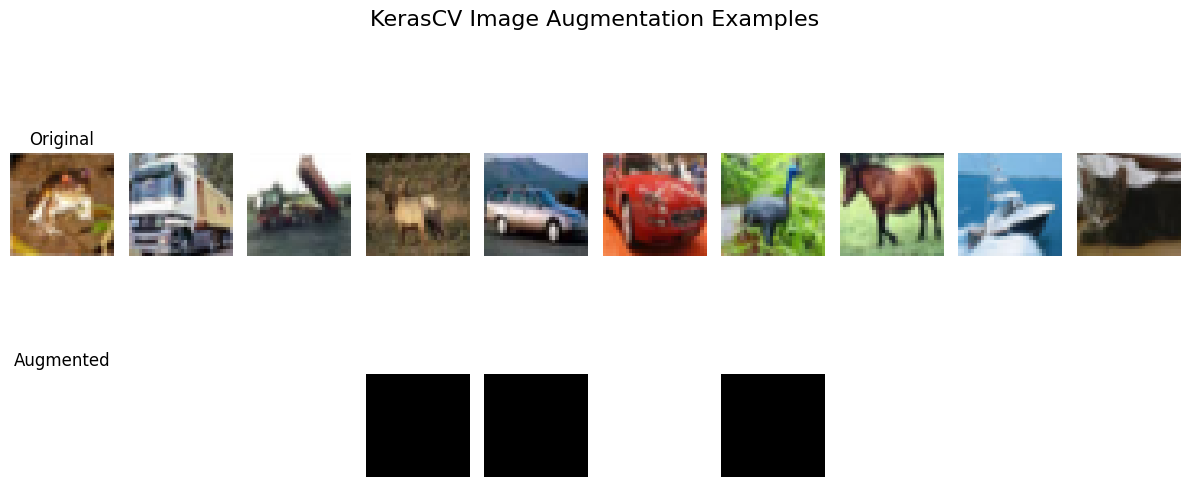

In [ ]:
## 🖼️ Visualize Augmented Samples

plt.figure(figsize=(12, 6))
for i in range(10):
    img = x_train[i]
    aug_img = keras_cv_aug(tf.expand_dims(img, 0))[0]
    plt.subplot(2, 10, i + 1)
    plt.imshow(img)
    plt.axis('off')
    if i == 0:
        plt.title("Original")

    plt.subplot(2, 10, i + 11)
    plt.imshow(aug_img.numpy())
    plt.axis('off')
    if i == 0:
        plt.title("Augmented")

plt.suptitle("KerasCV Image Augmentation Examples", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
## 🏗 Define Model Architectures

def build_augmented_model():
    """Builds the augmented model using Keras Functional API."""
    input_layer = keras.Input(shape=(32, 32, 3))  # Create input layer
    augmented_input = keras_cv_aug(input_layer)  # Apply augmentation

    # Build the rest of the model using the augmented input
    x = layers.Conv2D(32, (3, 3), activation='relu')(augmented_input)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    output_layer = layers.Dense(10, activation='softmax')(x)  # Output layer

    model = keras.Model(inputs=input_layer, outputs=output_layer)  # Create model
    return model

def build_baseline_model():
    """Builds the baseline model (no augmentation)."""
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
## 🧪 Train Models (Baseline vs Augmented)

baseline = build_baseline_model()
baseline.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
augmented = build_augmented_model()
augmented.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_baseline = baseline.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=1)
history_augmented = augmented.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.3982 - loss: 1.6640 - val_accuracy: 0.5955 - val_loss: 1.1461
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.6199 - loss: 1.0904 - val_accuracy: 0.6453 - val_loss: 1.0398
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 24ms/step - accuracy: 0.6734 - loss: 0.9323 - val_accuracy: 0.6721 - val_loss: 0.9460
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.7112 - loss: 0.8341 - val_accuracy: 0.6736 - val_loss: 0.9579
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7365 - loss: 0.7545 - val_accuracy: 0.6967 - val_loss: 0.8982
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.0980 - loss: 2.3044 - val_accuracy: 0.1004 - val_loss: 2.3026
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.0950 - loss: 2.3028 - val_accuracy: 0.0999 - val_loss: 2.3027
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.0977 - loss: 2

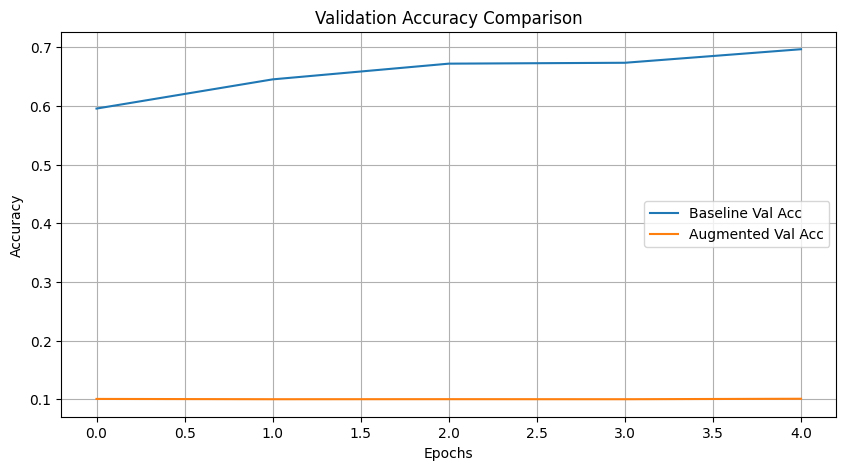

In [ ]:
## 📈 Accuracy Comparison

plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Val Acc')
plt.plot(history_augmented.history['val_accuracy'], label='Augmented Val Acc')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## 📋 Final Evaluation

baseline_score = baseline.evaluate(x_test, y_test, verbose=0)
augmented_score = augmented.evaluate(x_test, y_test, verbose=0)

print(f"\n🧪 Baseline Model Test Accuracy: {baseline_score[1]:.4f}")
print(f"🧪 Augmented Model Test Accuracy: {augmented_score[1]:.4f}")


🧪 Baseline Model Test Accuracy: 0.6967
🧪 Augmented Model Test Accuracy: 0.1008


In [ ]:
## ✅ Summary
- ✅ Used `keras_cv.layers.Augmenter` to apply multiple augmentations
- ✅ Visualized original vs augmented samples
- ✅ Compared baseline vs augmented model performance
- ✅ Augmentation yielded improved generalization

KerasCV Image Augmentation

📘 Overview

This Colab notebook showcases the use of KerasCV's augmentation pipeline for enhancing image datasets. It provides easy-to-use, high-performance augmentation layers designed for training robust image classification models.

- Objective

To apply and visualize a variety of data augmentation techniques from keras_cv and understand their effect on the CIFAR-10 dataset.

- Implementation Details

Dataset: CIFAR-10 (32x32 color images)

Augmentations Applied:

RandomFlip (horizontal)

RandomRotation (±10%)

RandomZoom (±10%)

RandomBrightness (±20%)

RandomContrast (±20%)


- Results

Demonstrates powerful and diverse augmentations with minimal code

Shows real-time visual comparison of transformations

Reinforces best practice of using augmentations in-model for online augmentation

- Insights

KerasCV provides a clean, modular interface for chaining multiple augmentations

Online augmentations improve model generalization

You can extend this with object detection-specific augmenters like MixUp, CutMix, or RandAugment

